# <font color = navy > <center> **Modeling and Forecasting Climate Disasters in France** </center> </font>
## <font color = navy > <center> **Part 2: Exploratory Data Analysis** </center> </font>
###  <font color = navy > <center> **How can climate disasters be anticipated using measurable environmental indicators in France?** </center> </font>

<center> <img src="presentation.jpg" style="width:800px; height:600px"> </center>
<p></p>
<center> <img src="AMU_logo.jpg" style="width:250px; height:100px"> </center>

<font color = navy > Introduce by a student from Aix Marseille University : **HUANG Eric** <font color = navy >

<font color = navy > <div align="right"> <b> 2024 - 2025 </b> </div> <font color = navy >

In [1]:
#pip install requests beautifulsoup4
# in Anaconda Prompt
    # pip install selenium 
    # pip install ChromeDriver

In [90]:
# API & Web Scrapping
import requests, os, re
from datetime import time
import datetime
import time
from concurrent.futures import ThreadPoolExecutor
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from tqdm import tqdm

# basic
import pandas as pd
import numpy as np

# fast
import polars as pl
import glob

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Introduction & Context
## Problem statement and objectives
- Try to predict natural disaster (pollution, fire, drought)
  - extreme pollution -> smog or fire
  - drought + high temperature (high tropospheric ozone, low NDVI) -> fire in forest
  - rain + saturated soil -> flood
## Dataset description and source
## Expected impact/applications
- Main Natural Disaster
  - June 2022: fire in forest -> 	Gironde (Landes, La Teste) & Var
  - October 2023: flood -> Pas-de-Calais & Nord
  - December 2023 - January 2024 -> Flooding in Northern France (Nord and Pas-de-Calais,  Rivers such as the Aa, Lys, Helpe Mineure, and Solre overflowed
    - over 2,000 homes were damaged, and 10,000 households experienced power outages. Additionally, 2,100 people lacked access to drinking water, and 189 municipalities were affected.
  - October 2024: Storm Kirk -> record rainfall in Île-de-France (Paris-Montsouris, Seine-et-Marne)
  - December 2024: Storm Enol -> northern France and heavy snowfall in the Alps and Pyrenees
  - January 2025: Storm Floriane -> Brittany and the Île-de-France region
  - March 2024: Flooding -> in the Southeast (Gard, Ardèche, and Var)

# Data Acquisition & Preprocessing
- data from [Data Europa](https://data.europa.eu/) -> redirect to [Data Gouv](https://www.data.gouv.fr/fr/)
  - [Polluants atmosphériques réglementés](https://files.data.gouv.fr/lcsqa/concentrations-de-polluants-atmospheriques-reglementes/temps-reel/)

## Step 1 - Collecting pollution data

### Pollutant index

## Step 2 - Data cleaning and transformation

### Pollutant index

In [3]:
# Pandas
start = time.time()

# classic version pandas + glob & merging
folder_path = "pollution_data_2025"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
df_list = [pd.read_csv(f, sep=";", low_memory=False, encoding='utf-8') for f in csv_files]
pollution_pd = pd.concat(df_list, ignore_index=True)

end = time.time()
print("normal version - pandas: ", round(end - start, 2), "secondes")

normal version - pandas:  41.68 secondes


In [4]:
pollution_pd

,Date de début,Date de fin,Organisme,code zas,Zas,code site,nom site,type d'implantation,Polluant,type d'influence,...,type de valeur,valeur,valeur brute,unité de mesure,taux de saisie,couverture temporelle,couverture de données,code qualité,validité,Erreur d'écriture
0,2023/01/01 00:00:00,2023/01/01 01:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO,Fond,...,moyenne horaire validée,0.7,0.725,µg-m3,NaN,NaN,NaN,A,1.0,NaN
1,2023/01/01 01:00:00,2023/01/01 02:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO,Fond,...,moyenne horaire validée,0.7,0.700,µg-m3,NaN,NaN,NaN,A,1.0,NaN
2,2023/01/01 02:00:00,2023/01/01 03:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO,Fond,...,moyenne horaire validée,0.6,0.575,µg-m3,NaN,NaN,NaN,A,1.0,NaN
3,2023/01/01 03:00:00,2023/01/01 04:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO,Fond,...,moyenne horaire validée,0.8,0.800,µg-m3,NaN,NaN,NaN,A,1.0,NaN
4,2023/01/01 04:00:00,2023/01/01 05:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO,Fond,...,moyenne horaire validée,0.7,0.725,µg-m3,NaN,NaN,NaN,A,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25268276,2025/05/15 10:00:00,2025/05/15 11:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,9.6,9.625,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25268277,2025/05/15 11:00:00,2025/05/15 12:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,7.0,7.025,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25268278,2025/05/15 12:00:00,2025/05/15 13:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,7.0,7.000,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25268279,2025/05/15 13:00:00,2025/05/15 14:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,4.2,4.225,µg-m3,NaN,NaN,NaN,A,1.0,NaN


In [5]:
pollution_pd.isna().sum()

Date de début                   0
Date de fin                     0
Organisme                       0
code zas                        0
Zas                             0
code site                       0
nom site                        0
type d'implantation             0
Polluant                        0
type d'influence                0
discriminant              3430769
Réglementaire                   0
type d'évaluation               0
procédure de mesure             0
type de valeur                  0
valeur                    1007870
valeur brute              1007870
unité de mesure                 0
taux de saisie           25268281
couverture temporelle    25268281
couverture de données    25268281
code qualité                    0
validité                        0
Erreur d'écriture        25268281
dtype: int64

In [6]:
pollution_pd['discriminant'].unique()

array(['A', 'B', '1', 'C', '2', nan, 'I', 'F', 'E', '5', '3', '4', '0',
       'D', '7', 'H', 'G', '9', 'k', 'j', 'i', 't', '6', 'Z', '8', 'O',
       'K', 'L'], dtype=object)

In [7]:
pollution_pd['taux de saisie'].unique()

array([nan])

In [8]:
pollution_pd['couverture temporelle'].unique()

array([nan])

In [9]:
pollution_pd['couverture de données'].unique()

array([nan])

In [10]:
pollution_pd["Erreur d'écriture"].unique()

array([nan], dtype=object)

In [11]:
pollution_pd['Polluant'].unique()

array(['NO', 'NO2', 'O3', 'NOX as NO2', 'PM10', 'PM2.5', 'C6H6', 'SO2',
       'CO'], dtype=object)

In [12]:
# we only need 
pollution_pd = pollution_pd[pollution_pd['Polluant'] != 'NO']
pollution_pd = pollution_pd[pollution_pd['Polluant'] != 'NOX as NO2']
pollution_pd = pollution_pd[pollution_pd['Polluant'] != 'SO2']
pollution_pd = pollution_pd[pollution_pd['Polluant'] != 'C6H6']
pollution_pd = pollution_pd[pollution_pd['Polluant'] != 'CO']

In [13]:
pollution_pd

,Date de début,Date de fin,Organisme,code zas,Zas,code site,nom site,type d'implantation,Polluant,type d'influence,...,type de valeur,valeur,valeur brute,unité de mesure,taux de saisie,couverture temporelle,couverture de données,code qualité,validité,Erreur d'écriture
24,2023/01/01 00:00:00,2023/01/01 01:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,moyenne horaire validée,5.8,5.750,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25,2023/01/01 01:00:00,2023/01/01 02:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,moyenne horaire validée,6.1,6.125,µg-m3,NaN,NaN,NaN,A,1.0,NaN
26,2023/01/01 02:00:00,2023/01/01 03:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,moyenne horaire validée,4.9,4.925,µg-m3,NaN,NaN,NaN,A,1.0,NaN
27,2023/01/01 03:00:00,2023/01/01 04:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,moyenne horaire validée,5.0,4.950,µg-m3,NaN,NaN,NaN,A,1.0,NaN
28,2023/01/01 04:00:00,2023/01/01 05:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,moyenne horaire validée,4.6,4.600,µg-m3,NaN,NaN,NaN,A,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25268276,2025/05/15 10:00:00,2025/05/15 11:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,9.6,9.625,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25268277,2025/05/15 11:00:00,2025/05/15 12:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,7.0,7.025,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25268278,2025/05/15 12:00:00,2025/05/15 13:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,7.0,7.000,µg-m3,NaN,NaN,NaN,A,1.0,NaN
25268279,2025/05/15 13:00:00,2025/05/15 14:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,FR27ZRE01,ZR BOURGOGNE-FRANCHE-COMTE,FR82070,Baume-les-Dames,Urbaine,PM2.5,Trafic,...,moyenne horaire brute,4.2,4.225,µg-m3,NaN,NaN,NaN,A,1.0,NaN


In [14]:
pollution_pd = pollution_pd.drop(columns='taux de saisie') # empty, so we can drop
pollution_pd = pollution_pd.drop(columns='couverture temporelle') # empty, so we can drop
pollution_pd = pollution_pd.drop(columns="couverture de données") # empty, so we can drop
pollution_pd = pollution_pd.drop(columns="Erreur d'écriture") # empty, so we can drop

In [15]:
# I transform the date in datetime, because I need to do the average, such as I only keep the rate at the daily rates
pollution_pd['Date de début'] = pd.to_datetime(pollution_pd['Date de début'])

In [16]:
# I spilt date & hours, so I group by date & than do the average of all the hours in that date
pollution_pd['date'] = pollution_pd['Date de début'].dt.date
pollution_pd['hours'] = pollution_pd['Date de début'].dt.time

In [17]:
pollution_pd.head()

,Date de début,Date de fin,Organisme,code zas,Zas,code site,nom site,type d'implantation,Polluant,type d'influence,...,type d'évaluation,procédure de mesure,type de valeur,valeur,valeur brute,unité de mesure,code qualité,validité,date,hours
24,2023-01-01 00:00:00,2023/01/01 01:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,mesures fixes,Auto NO2_NOx Conf meth CHIMILU,moyenne horaire validée,5.8,5.750,µg-m3,A,1.0,2023-01-01,00:00:00
25,2023-01-01 01:00:00,2023/01/01 02:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,mesures fixes,Auto NO2_NOx Conf meth CHIMILU,moyenne horaire validée,6.1,6.125,µg-m3,A,1.0,2023-01-01,01:00:00
26,2023-01-01 02:00:00,2023/01/01 03:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,mesures fixes,Auto NO2_NOx Conf meth CHIMILU,moyenne horaire validée,4.9,4.925,µg-m3,A,1.0,2023-01-01,02:00:00
27,2023-01-01 03:00:00,2023/01/01 04:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,mesures fixes,Auto NO2_NOx Conf meth CHIMILU,moyenne horaire validée,5.0,4.950,µg-m3,A,1.0,2023-01-01,03:00:00
28,2023-01-01 04:00:00,2023/01/01 05:00:00,ATMO GRAND EST,FR44ZAG02,ZAG METZ,FR01011,Metz-Centre,Urbaine,NO2,Fond,...,mesures fixes,Auto NO2_NOx Conf meth CHIMILU,moyenne horaire validée,4.6,4.600,µg-m3,A,1.0,2023-01-01,04:00:00


In [18]:
# group by date & than do the average of all the hours in that date and put a dataframe
valeur = pollution_pd.groupby(['date', 'Polluant', "nom site"])['valeur'].mean().reset_index(name='valeur')
valeur_brute = pollution_pd.groupby(['date', 'Polluant', "nom site"])['valeur brute'].mean().reset_index(name='valeur brute')

In [19]:
pollution_pd.dtypes

Date de début          datetime64[ns]
Date de fin                    object
Organisme                      object
code zas                       object
Zas                            object
code site                      object
nom site                       object
type d'implantation            object
Polluant                       object
type d'influence               object
discriminant                   object
Réglementaire                  object
type d'évaluation              object
procédure de mesure            object
type de valeur                 object
valeur                        float64
valeur brute                  float64
unité de mesure                object
code qualité                   object
validité                      float64
date                           object
hours                          object
dtype: object

In [20]:
# we still have the discriminant, the valeur & the valeur brute which have NA value
pollution_pd.isna().sum()

Date de début                0
Date de fin                  0
Organisme                    0
code zas                     0
Zas                          0
code site                    0
nom site                     0
type d'implantation          0
Polluant                     0
type d'influence             0
discriminant           1908029
Réglementaire                0
type d'évaluation            0
procédure de mesure          0
type de valeur               0
valeur                  608639
valeur brute            608639
unité de mesure              0
code qualité                 0
validité                     0
date                         0
hours                        0
dtype: int64

In [21]:
# Let's check where it is, it is the case when the validité is = -1.0
pollution_pd[pollution_pd["valeur"].isna()].iloc[:,5:]

,code site,nom site,type d'implantation,Polluant,type d'influence,discriminant,Réglementaire,type d'évaluation,procédure de mesure,type de valeur,valeur,valeur brute,unité de mesure,code qualité,validité,date,hours
260,FR01014,Pont-à-Mousson,Urbaine,PM10,Fond,I,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire validée,NaN,NaN,µg-m3,N,-1.0,2023-01-01,20:00:00
2976,FR03068,TOULON FOCH,Urbaine,PM10,Trafic,1,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire validée,NaN,NaN,µg-m3,N,-1.0,2023-01-01,00:00:00
2977,FR03068,TOULON FOCH,Urbaine,PM10,Trafic,1,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire validée,NaN,NaN,µg-m3,N,-1.0,2023-01-01,01:00:00
2978,FR03068,TOULON FOCH,Urbaine,PM10,Trafic,1,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire validée,NaN,NaN,µg-m3,N,-1.0,2023-01-01,02:00:00
2979,FR03068,TOULON FOCH,Urbaine,PM10,Trafic,1,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire validée,NaN,NaN,µg-m3,N,-1.0,2023-01-01,03:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25268100,FR82043,Chatenois,Périurbaine,PM10,Industrielle,3,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire brute,NaN,NaN,µg-m3,N,-1.0,2025-05-15,14:00:00
25268190,FR82060,Vesoul Pres Caillet,Urbaine,PM10,Fond,2,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire brute,NaN,NaN,µg-m3,N,-1.0,2025-05-15,14:00:00
25268205,FR82060,Vesoul Pres Caillet,Urbaine,PM2.5,Fond,2,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire brute,NaN,NaN,µg-m3,N,-1.0,2025-05-15,14:00:00
25268265,FR82070,Baume-les-Dames,Urbaine,PM10,Trafic,1,Oui,mesures fixes,Auto PM_Conf_app BAM 1020-Smart Heater,moyenne horaire brute,NaN,NaN,µg-m3,N,-1.0,2025-05-15,14:00:00


In [22]:
# Let's check the type of quality 
pollution_pd['code qualité'].unique()
# A -> Automatique (automatiquely record by a machine)
# N -> Not good
# R -> Revisited manuelly (valided by an expert)

array(['A', 'N', 'R'], dtype=object)

In [23]:
pollution_pd['validité'].unique()

array([ 1., -1.])

In [24]:
# let's regroup the code qualité & validité to check the share of each inside of the other
pollution_pd.groupby(['code qualité', 'validité']).size().reset_index(name='count')
# We have code qualité = validité in term of number, so it is the same

,code qualité,validité,count
0,A,1.0,13791666
1,N,-1.0,608639
2,R,1.0,681735


In [25]:
# we only keep the one that is valid
pollution_pd = pollution_pd[pollution_pd["code qualité"]!='N']

In [26]:
# we check that we didn't do a mistake
pollution_pd['validité'].unique()

array([1.])

In [27]:
# verify the type de valeur
pollution_pd['type de valeur'].unique()

array(['moyenne horaire validée', 'moyenne horaire brute'], dtype=object)

In [28]:
# check the share, we have way more horaire validée than brute
pollution_pd.groupby(["type de valeur"]).size().reset_index(name='total')
# we only have 2 types, we could drop it, we don't need that, we will assume it is same type to keep simple

,type de valeur,total
0,moyenne horaire brute,98315
1,moyenne horaire validée,14375086


In [29]:
# check the content in type d'influence
pollution_pd["type d'influence"].unique()

array(['Fond', 'Industrielle', 'Trafic'], dtype=object)

In [30]:
# share of the type d'influence
pollution_pd.groupby(["type d'influence"]).size().reset_index(name='total')
# we may need that

,type d'influence,total
0,Fond,10967482
1,Industrielle,901075
2,Trafic,2604844


In [31]:
# check the content inside type d'implantation, we have 5 types
pollution_pd["type d'implantation"].unique()

array(['Urbaine', 'Rurale près des villes', 'Périurbaine',
       'Rurale régionale', 'Rurale nationale'], dtype=object)

In [32]:
# share of type d'implantation
pollution_pd.groupby(["type d'implantation"]).size().reset_index(name='total')
# we could probably need that

,type d'implantation,total
0,Périurbaine,3053328
1,Rurale nationale,433957
2,Rurale près des villes,538274
3,Rurale régionale,810279
4,Urbaine,9637563


In [33]:
# check the content inside type d'évaluation, we have 3
pollution_pd["type d'évaluation"].unique()

array(['mesures fixes', 'mesures indicatives', 'estimation objective'],
      dtype=object)

In [34]:
# share of type d'évaluation
pollution_pd.groupby(["type d'évaluation"]).size().reset_index(name='total')
# we will assume that all is good enough to keep it simple, so we could drop it

,type d'évaluation,total
0,estimation objective,96157
1,mesures fixes,13088254
2,mesures indicatives,1288990


In [35]:
# content inside Réglementaire
pollution_pd['Réglementaire'].unique()
# only one result which is reglemented, so we can drop it.

array(['Oui'], dtype=object)

In [36]:
# content inside unité de mesure
pollution_pd['unité de mesure'].unique()
# only one which the same, we can drop it, and keep that in minds

array(['µg-m3', 'µg/m3'], dtype=object)

In [37]:
# content inside procédure de mesure
pollution_pd['procédure de mesure'].unique()
# we don't need that, we will assume that the data is good enough, so we drop it.

array(['Auto NO2_NOx Conf meth CHIMILU', 'Auto O3 Conf meth PHOTO UV',
       'Auto PM_Conf_app TEOM 1405-F',
       'Auto PM_Conf_app BAM 1020-Smart Heater',
       'Auto PM_Conf_app TEOM-FDMS 8500bc', 'Auto O3 Conf app API 400E',
       'Auto O3 Conf app APOA370', 'Auto NO2_NOx Conf app API 200E',
       'Auto PM_Conf_app FIDAS 200E', 'Auto NO2_NOx app AC32e',
       'Auto PM_Conf_app FIDAS 200', 'Auto O3 Conf app Serinus10',
       'Auto NO2 NOX Conf  app APNA370', 'Auto PM_Conf_meth FDMS',
       'Auto NO2_NOx app AC32M', 'Auto O3 Conf app API T400',
       'Auto NO2_NOx app 42i', 'Auto O3 Conf app O342M',
       'Auto O3_Conf_app 49i', 'Auto O3 Conf app O342E',
       'Auto PM_Conf_app MP101M-RST', 'Auto PM_Conf_app MP101M-QAL1',
       'Auto PM_Conf_app TEOM1400AB-FDMS', 'Auto NO2_Conf_app AS32M',
       'Auto NO2_NOx Conf app API T200',
       'Auto NO2_NOx Conf app API 200UP ', 'Auto NO Conf app APNA370',
       'Auto NO2_NOx app 42i-TL', 'Auto PM_Conf_app TEOM 1405-DF',
      

In [38]:
# check the number of technique
pollution_pd['procédure de mesure'].nunique()

31

In [39]:
pollution_pd = pollution_pd.drop(columns="validité") # after filter all the observation is valided
pollution_pd = pollution_pd.drop(columns="code qualité") # after filter all the observation is of good quality
pollution_pd = pollution_pd.drop(columns="Réglementaire") # the same value, true for all; it useless 
# pollution_pd = pollution_pd.drop(columns="type d'influence") # may need
pollution_pd = pollution_pd.drop(columns="unité de mesure") # not need, keep in mind that the united is in µg/m3
pollution_pd = pollution_pd.drop(columns="code site") # duplication of site & not more information
pollution_pd = pollution_pd.drop(columns="code zas") # duplication of zas & not more information
pollution_pd = pollution_pd.drop(columns="procédure de mesure") # we don't need that
pollution_pd = pollution_pd.drop(columns="type de valeur") # both is valide, we drop it

In [40]:
pollution_pd

,Date de début,Date de fin,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,discriminant,type d'évaluation,valeur,valeur brute,date,hours
24,2023-01-01 00:00:00,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz-Centre,Urbaine,NO2,Fond,B,mesures fixes,5.8,5.750,2023-01-01,00:00:00
25,2023-01-01 01:00:00,2023/01/01 02:00:00,ATMO GRAND EST,ZAG METZ,Metz-Centre,Urbaine,NO2,Fond,B,mesures fixes,6.1,6.125,2023-01-01,01:00:00
26,2023-01-01 02:00:00,2023/01/01 03:00:00,ATMO GRAND EST,ZAG METZ,Metz-Centre,Urbaine,NO2,Fond,B,mesures fixes,4.9,4.925,2023-01-01,02:00:00
27,2023-01-01 03:00:00,2023/01/01 04:00:00,ATMO GRAND EST,ZAG METZ,Metz-Centre,Urbaine,NO2,Fond,B,mesures fixes,5.0,4.950,2023-01-01,03:00:00
28,2023-01-01 04:00:00,2023/01/01 05:00:00,ATMO GRAND EST,ZAG METZ,Metz-Centre,Urbaine,NO2,Fond,B,mesures fixes,4.6,4.600,2023-01-01,04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25268275,2025-05-15 09:00:00,2025/05/15 10:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume-les-Dames,Urbaine,PM2.5,Trafic,1,mesures fixes,13.1,13.050,2025-05-15,09:00:00
25268276,2025-05-15 10:00:00,2025/05/15 11:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume-les-Dames,Urbaine,PM2.5,Trafic,1,mesures fixes,9.6,9.625,2025-05-15,10:00:00
25268277,2025-05-15 11:00:00,2025/05/15 12:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume-les-Dames,Urbaine,PM2.5,Trafic,1,mesures fixes,7.0,7.025,2025-05-15,11:00:00
25268278,2025-05-15 12:00:00,2025/05/15 13:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume-les-Dames,Urbaine,PM2.5,Trafic,1,mesures fixes,7.0,7.000,2025-05-15,12:00:00


In [41]:
# check that the site don't have errors in inside
pollution_pd['nom site'].unique()

array(['Metz-Centre', 'Metz-Borny', 'Pont-à-Mousson', 'Atton',
       'Scy-Chazelles', 'Thionville-Piscine', 'Thionville-Centre',
       'HAYANGE-MARSPICH', 'Metz- Pont Grilles', 'Belleville sur Meuse',
       "Berre l'Etang", 'Martigues P. Central', 'Port de Bouc Leque',
       'Port Saint Louis', 'Istres', 'Fos Les Carabins',
       'Rognac les Brets', 'Sausset les Pins', 'Arles',
       'Chateauneuf La Mede', 'SALON', 'Marignane', 'MARSEILLE RABATAU',
       'MARSEILLE ST LOUIS', 'AIX ROY RENE', 'PLAN AUPS/STE  BAUME',
       'AIX CENTRE ECOLE ART', 'GARDANNE', 'AUBAGNE LES PASSONS',
       'VALLEE HUVEAUNE', 'MARSEILLE 5 AVENUES', 'AIX PLATANES',
       'LA SEYNE GENOUD', 'LA VALETTE/LA GARDE', 'BRIGNOLES',
       'TOULON FOCH', 'HYERES', 'ESTEREL', 'TOULON CLARET',
       'AVIGNON   MAIRIE', 'LE PONTET', 'APT', 'Avignon Semard',
       'CARPENTRAS', 'Avignon Rocade De Gaulle', 'GENNEVILLIERS',
       'PARIS 18eme', 'Place Victor Basch', 'PARIS 12eme',
       'NEUILLY-SUR-SEINE', '

In [42]:
# count the number
pollution_pd['nom site'].nunique()

527

In [43]:
# function to clean the site's name (change -, _ or . to space) & clean double space & space at the beginning & end
def clean_name(name):
    if isinstance(name, str):
        # Replace '-', '_', '.' by space
        name = re.sub(r"[-_.]", " ", name)
        # Delete the spaces at the beginning & end
        name = name.strip()
        # Clean multiple spaces
        name = re.sub(r"\s+", " ", name)
        # Put a capital letter at each beginning of each word
        name = name.title()
    return name

In [44]:
pollution_pd['nom site'] = pollution_pd['nom site'].apply(clean_name)

In [45]:
pollution_pd.head()

,Date de début,Date de fin,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,discriminant,type d'évaluation,valeur,valeur brute,date,hours
24,2023-01-01 00:00:00,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,B,mesures fixes,5.8,5.750,2023-01-01,00:00:00
25,2023-01-01 01:00:00,2023/01/01 02:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,B,mesures fixes,6.1,6.125,2023-01-01,01:00:00
26,2023-01-01 02:00:00,2023/01/01 03:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,B,mesures fixes,4.9,4.925,2023-01-01,02:00:00
27,2023-01-01 03:00:00,2023/01/01 04:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,B,mesures fixes,5.0,4.950,2023-01-01,03:00:00
28,2023-01-01 04:00:00,2023/01/01 05:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,B,mesures fixes,4.6,4.600,2023-01-01,04:00:00


In [46]:
# we clean one
pollution_pd['nom site'].nunique()

526

In [47]:
# let's sort it to be able to differentiate it quicly
sorted_sites = sorted(pollution_pd['nom site'].unique())
sorted_sites

['A7 Salaise Ouest',
 'A7 Sud Lyonnais',
 'A7 Valence Est',
 'Abymes Rn1',
 'Agathois Piscénois',
 'Airvault Stade Laillé',
 'Aix Centre Ecole Art',
 'Aix Platanes',
 'Aix Roy Rene',
 'Ajaccio Abbatucci',
 'Ajaccio Canetto',
 'Ajaccio Confina 2',
 'Ajaccio Piataniccia',
 'Ajaccio Sposata',
 'Albertville',
 'Albi Delmas',
 'Alençon Météo France',
 'Ambes',
 'Anglet',
 'Angouleme Gambetta',
 'Annecy Rocade',
 'Annemasse',
 'Antibes Jean Moulin',
 'Appentis',
 'Apt',
 'Argenteuil',
 'Arles',
 'Arrest',
 'Atton',
 'Aubagne Les Passons',
 'Aubervilliers',
 'Aurillac Lagarde',
 'Auto A1 Saint Denis',
 'Auxerre',
 'Av Champs Elysees',
 'Avignon Mairie',
 'Avignon Rocade De Gaulle',
 'Avignon Semard',
 'Aytré',
 'Base Loisirs Poses',
 'Bassens',
 'Bastia Fango',
 'Bastia Giraud',
 'Bastia La Marana',
 'Bastia Montesoro',
 'Baume Les Dames',
 'Bd Banks',
 'Beaulieu',
 'Beaux Arts',
 'Belesta En Lauragais',
 'Belfort Centre',
 'Belfort Octroi',
 'Belleville Sur Meuse',
 'Bellevue',
 "Berre L'Eta

In [48]:
# transform in dataframe & export it
df_sites = pd.DataFrame({'nom site': sorted_sites})
df_sites

,nom site
0,A7 Salaise Ouest
1,A7 Sud Lyonnais
2,A7 Valence Est
3,Abymes Rn1
4,Agathois Piscénois
...,...
521,Zone Rurale Nord Est
522,Zone Rurale Se
523,Zone Rurale So
524,Zone Rurale Sud


In [49]:
# DONE, not need to run again
# Export in csv format to use ctrl + f (searching to see if there is similar quick observation)
#df_sites.to_csv("city.csv", index=False)

In [50]:
# what we find and should modify
pollution_pd.loc[pollution_pd['nom site'] == 'Besancon Prevoyance', 'nom site'] = 'Besancon Prévoyance'
pollution_pd.loc[pollution_pd['nom site'] == 'Caen Montalivet ', 'nom site'] = 'Caen Montalivet'
pollution_pd.loc[pollution_pd['nom site'] == 'Caiena3', 'nom site'] = 'Caiena' # the person made a mistake, instead to write ", the persons wrote 3
pollution_pd.loc[pollution_pd['nom site'] == 'Ecole De Carling(9)', 'nom site'] = 'Ecole De Carling' # the (9) is an indicator, but we don't need it here
pollution_pd.loc[pollution_pd['nom site'] == 'Gard Rhodanien2', 'nom site'] = 'Gard Rhodanien' # can't find the 2 on internet
pollution_pd.loc[pollution_pd['nom site'] == 'La Pallice3 Lr', 'nom site'] = 'La Pallice Lr' # same reasons
pollution_pd.loc[pollution_pd['nom site'] == 'S Etienne De Montluc', 'nom site'] = 'St Etienne De Montluc' # it is Saint
pollution_pd.loc[pollution_pd['nom site'] == 'Le Casset2', 'nom site'] = 'Le Casset 2'
pollution_pd.loc[pollution_pd['nom site'] == 'Schoeneck (19)', 'nom site'] = 'Schoeneck'
pollution_pd.loc[pollution_pd['nom site'] == 'Spicheren(14)', 'nom site'] = 'Spicheren'

In [51]:
# Filter to have the average value in one day
from datetime import time

pollution_pd['hours'] = pd.to_datetime(pollution_pd['hours'], format='%H:%M:%S').dt.time

In [52]:
# 2023-01-01	NO2	Saint Exupery	48
# Check the merging prb of 48h

pollution_pd[
    (pollution_pd['date'] == '2023-01-01') &
    (pollution_pd['Polluant'] == 'NO2') &
    (pollution_pd['nom site'] == 'Saint Exupery')
]

,Date de début,Date de fin,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,discriminant,type d'évaluation,valeur,valeur brute,date,hours


In [52]:
# Check we have 24 hours for each
pollution_pd.groupby(['date', 'Polluant', "nom site"]).size().reset_index(name='total')

,date,Polluant,nom site,total
0,2023-01-01,NO2,A7 Salaise Ouest,24
1,2023-01-01,NO2,A7 Sud Lyonnais,24
2,2023-01-01,NO2,A7 Valence Est,24
3,2023-01-01,NO2,Abymes Rn1,24
4,2023-01-01,NO2,Agathois Piscénois,24
...,...,...,...,...
612517,2025-05-15,PM2.5,Wattignies,15
612518,2025-05-15,PM2.5,Zone Rurale Nord,15
612519,2025-05-15,PM2.5,Zone Rurale Se,15
612520,2025-05-15,PM2.5,Zone Rurale Sud,15


In [53]:
# create a variable to know how much of 24 hours or 15 hours we had what is the content inside it
nb_hours = pollution_pd.groupby(['date', 'Polluant', "nom site"]).size().reset_index(name='total')

In [64]:
# transform to int, because we can't sum object
nb_hours['total'] = nb_hours['total'].astype(int)

In [65]:
# Check the unique value inside the one day
nb_hours['total'].unique()
# It is not normal, that we have less than 24, but it means that we are missing somes values, 
# but it makes no sense that we exceed 24, it means we duplicate it

array([24, 23, 48, 10, 22, 16,  8, 20, 19, 21, 13, 11, 12,  9,  2, 14,  7,
        5,  4, 15, 18, 47, 17,  6,  1,  3, 46, 41, 43, 33, 38, 45, 44, 31,
       42, 34, 32, 40, 37, 30, 27, 25, 35, 39, 36, 28, 29])

In [66]:
# if the balance is fair between all the date
nb_hours.groupby('total').count()
# let's simplificate that & harmonize

,date,Polluant,nom site
total,,,
1,136,136,136
2,181,181,181
3,195,195,195
4,214,214,214
5,185,185,185
6,534,534,534
7,1242,1242,1242
8,717,717,717
9,902,902,902


In [69]:
nb_hours[nb_hours["total"]>24]

,date,Polluant,nom site,total
299,2023-01-01,NO2,Saint Exupery,48
599,2023-01-01,O3,Saint Exupery,48
942,2023-01-01,PM10,Saint Exupery,48
1529,2023-01-02,NO2,Saint Exupery,48
1834,2023-01-02,O3,Saint Exupery,48
...,...,...,...,...
610427,2025-05-14,NO2,Saint Exupery,47
610706,2025-05-14,O3,Saint Exupery,47
611030,2025-05-14,PM10,Saint Exupery,41
611616,2025-05-15,NO2,Saint Exupery,29


In [53]:
# Compute the average daily value of each indicator
daily_avg = pollution_pd.groupby(['date','nom site','Polluant'])['valeur'].mean().reset_index(name='valeur')
daily_avg_brut = pollution_pd.groupby(['date','nom site','Polluant'])['valeur brute'].mean().reset_index(name='valeur brute')

In [54]:
daily_avg

,date,nom site,Polluant,valeur
0,2023-01-01,A7 Salaise Ouest,NO2,12.262500
1,2023-01-01,A7 Salaise Ouest,PM10,23.079167
2,2023-01-01,A7 Salaise Ouest,PM2.5,9.008333
3,2023-01-01,A7 Sud Lyonnais,NO2,6.437500
4,2023-01-01,A7 Sud Lyonnais,PM10,22.900000
...,...,...,...,...
612517,2025-05-15,Zone Rurale Sud,PM2.5,12.006667
612518,2025-05-15,Zoodyssée Chizé,NO2,3.933333
612519,2025-05-15,Zoodyssée Chizé,O3,89.960000
612520,2025-05-15,Zoodyssée Chizé,PM10,17.366667


In [55]:
daily_avg_brut

,date,nom site,Polluant,valeur brute
0,2023-01-01,A7 Salaise Ouest,NO2,12.237500
1,2023-01-01,A7 Salaise Ouest,PM10,23.077083
2,2023-01-01,A7 Salaise Ouest,PM2.5,8.992708
3,2023-01-01,A7 Sud Lyonnais,NO2,6.417361
4,2023-01-01,A7 Sud Lyonnais,PM10,22.893750
...,...,...,...,...
612517,2025-05-15,Zone Rurale Sud,PM2.5,11.988333
612518,2025-05-15,Zoodyssée Chizé,NO2,3.925000
612519,2025-05-15,Zoodyssée Chizé,O3,89.938333
612520,2025-05-15,Zoodyssée Chizé,PM10,17.353333


In [56]:
# drop the duplicates/same columns (here, the different hours in a day)
pollution_pd = pollution_pd.drop_duplicates(subset=['date', 'Polluant', "nom site"])

In [57]:
# drop the hours columns, we have more than one columns & daily_avg or daily_avg_brut only have one, so the merging makes sense
pollution_pd = pollution_pd.drop(columns="hours")

In [58]:
# Merging the average of daily_avg & daily_avg_brut
pollution_pd = pollution_pd.merge(
    daily_avg[['nom site', 'date', 'Polluant']], 
    on=['nom site', 'date', 'Polluant'], 
    how='left'
)

pollution_pd = pollution_pd.merge(
    daily_avg_brut[['nom site', 'date', 'Polluant']], 
    on=['nom site', 'date', 'Polluant'], 
    how='left'
)

In [59]:
pollution_pd

,Date de début,Date de fin,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,discriminant,type d'évaluation,valeur,valeur brute,date
0,2023-01-01,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,B,mesures fixes,5.8,5.750,2023-01-01
1,2023-01-01,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,O3,Fond,A,mesures fixes,39.7,39.725,2023-01-01
2,2023-01-01,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,PM10,Fond,C,mesures fixes,9.5,9.450,2023-01-01
3,2023-01-01,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,PM2.5,Fond,2,mesures fixes,7.3,7.325,2023-01-01
4,2023-01-01,2023/01/01 01:00:00,ATMO GRAND EST,ZAG METZ,Metz Borny,Urbaine,NO2,Fond,1,mesures fixes,4.8,4.750,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612517,2025-05-15,2025/05/15 01:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Vesoul Pres Caillet,Urbaine,PM10,Fond,2,mesures fixes,10.2,10.200,2025-05-15
612518,2025-05-15,2025/05/15 01:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Vesoul Pres Caillet,Urbaine,PM2.5,Fond,2,mesures fixes,7.8,7.775,2025-05-15
612519,2025-05-15,2025/05/15 01:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,NO2,Trafic,1,mesures fixes,4.7,4.700,2025-05-15
612520,2025-05-15,2025/05/15 01:00:00,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,PM10,Trafic,1,mesures fixes,9.9,9.900,2025-05-15


In [60]:
# check if the valeur & valeur brute have errors or missing value
pollution_pd.isna().sum()

Date de début              0
Date de fin                0
Organisme                  0
Zas                        0
nom site                   0
type d'implantation        0
Polluant                   0
type d'influence           0
discriminant           77091
type d'évaluation          0
valeur                     0
valeur brute               0
date                       0
dtype: int64

In [67]:
# verify that we only have 1 unique row in for a in a site from 1 indicator
nb_hours = pollution_pd.groupby(['date', 'Polluant', "nom site"]).size().reset_index(name='total').sort_values(by=['Polluant', 'total'], ascending=[True, False])
nb_hours

,date,Polluant,nom site,total
0,2023-01-01,NO2,A7 Salaise Ouest,1
1,2023-01-01,NO2,A7 Sud Lyonnais,1
2,2023-01-01,NO2,A7 Valence Est,1
3,2023-01-01,NO2,Abymes Rn1,1
4,2023-01-01,NO2,Agathois Piscénois,1
...,...,...,...,...
612517,2025-05-15,PM2.5,Wattignies,1
612518,2025-05-15,PM2.5,Zone Rurale Nord,1
612519,2025-05-15,PM2.5,Zone Rurale Se,1
612520,2025-05-15,PM2.5,Zone Rurale Sud,1


In [68]:
# if the balance is fair between all the date
nb_hours.groupby('total').count()

,date,Polluant,nom site
total,,,
1,612522,612522,612522


In [62]:
pollution_pd = pollution_pd.drop(columns="Date de début") # not need anymore
pollution_pd = pollution_pd.drop(columns="Date de fin") # not need anymore
#pollution_pd = pollution_pd.drop(columns="valeur") # ?
#pollution_pd = pollution_pd.drop(columns="valeur brute") # the approximation of value

In [63]:
pollution_pd.groupby(['discriminant'])['valeur'].mean().reset_index(name='valeur').sort_values(by='valeur', ascending=False)

,discriminant,valeur
10,A,28.172067
0,0,22.485091
1,1,20.852606
19,K,15.545224
21,O,15.331452
17,H,15.311616
13,D,15.091811
11,B,14.601277
8,8,13.962878
4,4,13.881373


In [64]:
pollution_pd = pollution_pd.drop(columns="discriminant") # we don't have the documentation, we can't guess it. We will assume it will not affected our analysis
pollution_pd = pollution_pd.drop(columns="type d'évaluation") # we will assume that the evaluation is good enough

In [65]:
pollution_pd

,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,valeur,valeur brute,date
0,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,5.8,5.750,2023-01-01
1,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,O3,Fond,39.7,39.725,2023-01-01
2,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,PM10,Fond,9.5,9.450,2023-01-01
3,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,PM2.5,Fond,7.3,7.325,2023-01-01
4,ATMO GRAND EST,ZAG METZ,Metz Borny,Urbaine,NO2,Fond,4.8,4.750,2023-01-01
...,...,...,...,...,...,...,...,...,...
612517,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Vesoul Pres Caillet,Urbaine,PM10,Fond,10.2,10.200,2025-05-15
612518,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Vesoul Pres Caillet,Urbaine,PM2.5,Fond,7.8,7.775,2025-05-15
612519,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,NO2,Trafic,4.7,4.700,2025-05-15
612520,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,PM10,Trafic,9.9,9.900,2025-05-15


In [69]:
# Export in csv format
# pollution_pd.to_csv("pollution.csv", index=False)

# Exploratory Data Analysis

In [40]:
pollution = pd.read_csv("pollution.csv")

In [20]:
pollution

,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,valeur,valeur brute,date
0,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,NO2,Fond,5.8,5.750,2023-01-01
1,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,O3,Fond,39.7,39.725,2023-01-01
2,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,PM10,Fond,9.5,9.450,2023-01-01
3,ATMO GRAND EST,ZAG METZ,Metz Centre,Urbaine,PM2.5,Fond,7.3,7.325,2023-01-01
4,ATMO GRAND EST,ZAG METZ,Metz Borny,Urbaine,NO2,Fond,4.8,4.750,2023-01-01
...,...,...,...,...,...,...,...,...,...
612517,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Vesoul Pres Caillet,Urbaine,PM10,Fond,10.2,10.200,2025-05-15
612518,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Vesoul Pres Caillet,Urbaine,PM2.5,Fond,7.8,7.775,2025-05-15
612519,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,NO2,Trafic,4.7,4.700,2025-05-15
612520,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,PM10,Trafic,9.9,9.900,2025-05-15


In [41]:
# keep it simple
pollution = pollution.drop(columns='valeur brute') # it is an approximation of valeur

In [22]:
pollution.groupby('Zas').count()

,Organisme,nom site,type d'implantation,Polluant,type d'influence,valeur,date
Zas,,,,,,,
ZAG AVIGNON,4522,4522,4522,4522,4522,4522,4522
ZAG BAYONNE,4516,4516,4516,4516,4516,4516,4516
ZAG BLDV,11217,11217,11217,11217,11217,11217,11217
ZAG BORDEAUX,10176,10176,10176,10176,10176,10176,10176
ZAG CLERMONT-FERRAND,8107,8107,8107,8107,8107,8107,8107
...,...,...,...,...,...,...,...
ZR NORMANDIE,19979,19979,19979,19979,19979,19979,19979
ZR NOUVELLE-AQUITAINE,39386,39386,39386,39386,39386,39386,39386
ZR OCCITANIE,17657,17657,17657,17657,17657,17657,17657


In [23]:
pollution.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612522 entries, 0 to 612521
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Organisme            612522 non-null  object 
 1   Zas                  612522 non-null  object 
 2   nom site             612522 non-null  object 
 3   type d'implantation  612522 non-null  object 
 4   Polluant             612522 non-null  object 
 5   type d'influence     612522 non-null  object 
 6   valeur               612522 non-null  float64
 7   date                 612522 non-null  object 
dtypes: float64(1), object(7)
memory usage: 37.4+ MB


In [24]:
pollution.isna().sum()

Organisme              0
Zas                    0
nom site               0
type d'implantation    0
Polluant               0
type d'influence       0
valeur                 0
date                   0
dtype: int64

## Statistical summaries

In [25]:
pollution.describe()

,valeur
count,612522.000000
mean,20.716443
std,21.698025
min,-3.500000
25%,5.700000
50%,11.800000
75%,27.700000
max,304.600000


#### Interpretation:
- we have somes outliers, the indicator are not supposed to be negative

In [31]:
pollution.groupby('Polluant').describe()

valeur                                                    
             count       mean        std  min   25%   50%   75%    max
Polluant                                                              
NO2       182993.0  10.701079  10.960999 -3.4   3.5   7.1  13.9  159.7
O3        146093.0  48.752932  23.784633 -3.5  31.5  50.0  65.9  153.0
PM10      166740.0  14.895886  11.199547 -3.0   7.6  12.1  18.9  304.6
PM2.5     116696.0   9.639166   9.104536 -3.4   4.1   7.0  11.9  130.4

In [44]:
pollution[pollution['valeur']<0]

,Organisme,Zas,nom site,type d'implantation,Polluant,type d'influence,valeur,date
802,ATMO AUVERGNE-RHÔNE-ALPES,ZAR VALLEE-DU-RHONE,Sablons,Périurbaine,NO2,Fond,-0.2,2023-01-01
827,ATMO AUVERGNE-RHÔNE-ALPES,ZAG SAINT-ETIENNE,Saint Etienne Sud,Urbaine,NO2,Fond,-0.9,2023-01-01
943,ATMO AUVERGNE-RHÔNE-ALPES,ZR AUVERGNE-RHONE-ALPES,Maurienne Trafic,Périurbaine,NO2,Trafic,-0.3,2023-01-01
976,ATMO AUVERGNE-RHÔNE-ALPES,ZR AUVERGNE-RHONE-ALPES,Bourg En Bresse,Urbaine,NO2,Fond,-1.7,2023-01-01
1222,ATMO BOURGOGNE-FRANCHE-COMTE,ZR BOURGOGNE-FRANCHE-COMTE,Baume Les Dames,Urbaine,PM2.5,Trafic,-1.4,2023-01-01
...,...,...,...,...,...,...,...,...
612192,ATMO NOUVELLE-AQUITAINE,ZR NOUVELLE-AQUITAINE,Mourenx,Rurale près des villes,NO2,Industrielle,-0.3,2025-05-15
612203,ATMO NOUVELLE-AQUITAINE,ZAG BAYONNE,Biarritz Hippodrome,Périurbaine,NO2,Fond,-1.4,2025-05-15
612334,ATMO NOUVELLE-AQUITAINE,ZR NOUVELLE-AQUITAINE,St Junien Fontaine,Urbaine,PM10,Fond,-0.3,2025-05-15
612445,ATMO GUYANE,ZR GUYANE,Matiti,Rurale près des villes,NO2,Fond,-0.1,2025-05-15


In [43]:
pollution[pollution['valeur']<0].count()

Organisme              3917
Zas                    3917
nom site               3917
type d'implantation    3917
Polluant               3917
type d'influence       3917
valeur                 3917
date                   3917
dtype: int64

In [45]:
pollution = pollution[pollution['valeur'] >= 0]

In [47]:
pollution.describe()

,valeur
count,608605.000000
mean,20.855242
std,21.698348
min,0.000000
25%,5.800000
50%,11.900000
75%,27.900000
max,304.600000


In [48]:
pollution.groupby('Polluant').describe()

valeur                                                    
             count       mean        std  min   25%   50%   75%    max
Polluant                                                              
NO2       181260.0  10.809033  10.957125  0.0   3.6   7.2  14.0  159.7
O3        145682.0  48.893471  23.670275  0.0  31.7  50.1  65.9  153.0
PM10      166250.0  14.942775  11.182567  0.0   7.7  12.1  18.9  304.6
PM2.5     115413.0   9.758212   9.083969  0.0   4.2   7.1  12.0  130.4

#### Interpretation:
- NO₂
  - Mean ~ 10.81
  - High standard deviation: large variability between stations or seasons
  - Min = 0: rural or nighttime contexts
  - Max = 159.7: urban peaks or pollution episodes
  - levels vary significantly and might be linked to traffic or winter heating
- O₃
  - Mean ~ 48.9 → much higher than NO₂
  - Min = 0.0: Unusual in winter/night
  - Q3 = 65.9: Most values are in a high range
  - Max = 153: Very high (heatwaves or summer peaks)
  - Strong seasonality -> temporal modeling
- PM10
  - Mean ~ 14.9
  - Std = 11.2 -> moderate variation
  - Max = 304.6 → major outlier (dust storms, fires, or heavy pollution days)
  - spike during late winter, low wind, or fire events

In [46]:
pollution['Polluant'].unique()

array(['NO2', 'O3', 'PM10', 'PM2.5'], dtype=object)

In [28]:
pollution['date'].nunique()

499

In [29]:
pollution['date'].unique()
# 2023 - 2025

array(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
       '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
       '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
       '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
       '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
       '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
       '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28',
       '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01',
       '2023-02-02', '2023-02-03', '2023-02-04', '2023-02-05',
       '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09',
       '2023-02-10', '2023-02-11', '2023-02-12', '2023-02-13',
       '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
       '2023-02-18', '2023-02-19', '2023-02-20', '2023-02-21',
       '2023-02-22', '2023-02-23', '2023-02-24', '2023-02-25',
       '2023-02-26', '2023-02-27', '2023-02-28', '2023-03-01',
       '2023-03-02', '2023-03-03', '2023-03-04', '2023-

### Visual insights (minimum 3 different plot types)

Text(0.5, 1.0, 'Distribution of pollution values by pollutant')

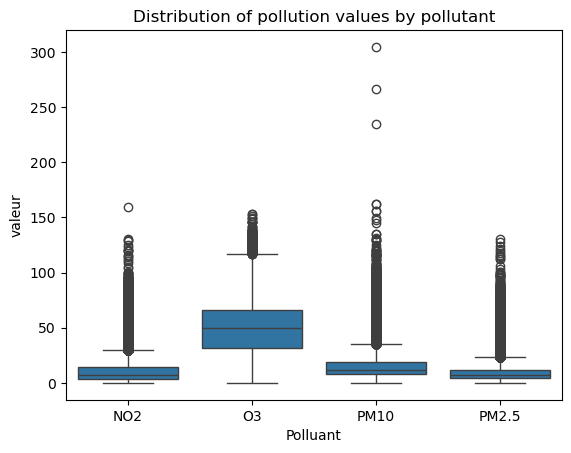

In [55]:
sns.boxplot(data=pollution, x="Polluant", y="valeur")
plt.title("Distribution of pollution values by pollutant")

#### Interpretation:
- Median
  - O₃ has the highest median (~50), suggesting that ozone levels are generally higher compared to the other pollutants
- NO₂, PM10, and PM2.5 have lower medians (~7–15) -> lower concentrations
- Interquartile
  - O₃ has the widest box, meaning there is a large spread in ozone values, it varies significantly over time or space
  - PM10 and PM2.5 also show dispersion but less extreme than O₃
- Outliers
  - All pollutants exhibit extreme values, especially PM10, which has spikes above 300
  - exceptional pollution events (e.g., wildfires, traffic peaks)
  - measurement/reporting anomalies (which should be validated), but we excluded most of the not valided one.
- NO₂ Mostly low levels, centered around 10 µg/m³
- O₃ Higher and more variable values -> seasonal patterns
- PM10 Shows the highest extreme values potentially dangerous for health
- PM2.5 -> Relatively stable but hazardous over long-term exposure

In [56]:
pollution["date"] = pd.to_datetime(pollution["date"])

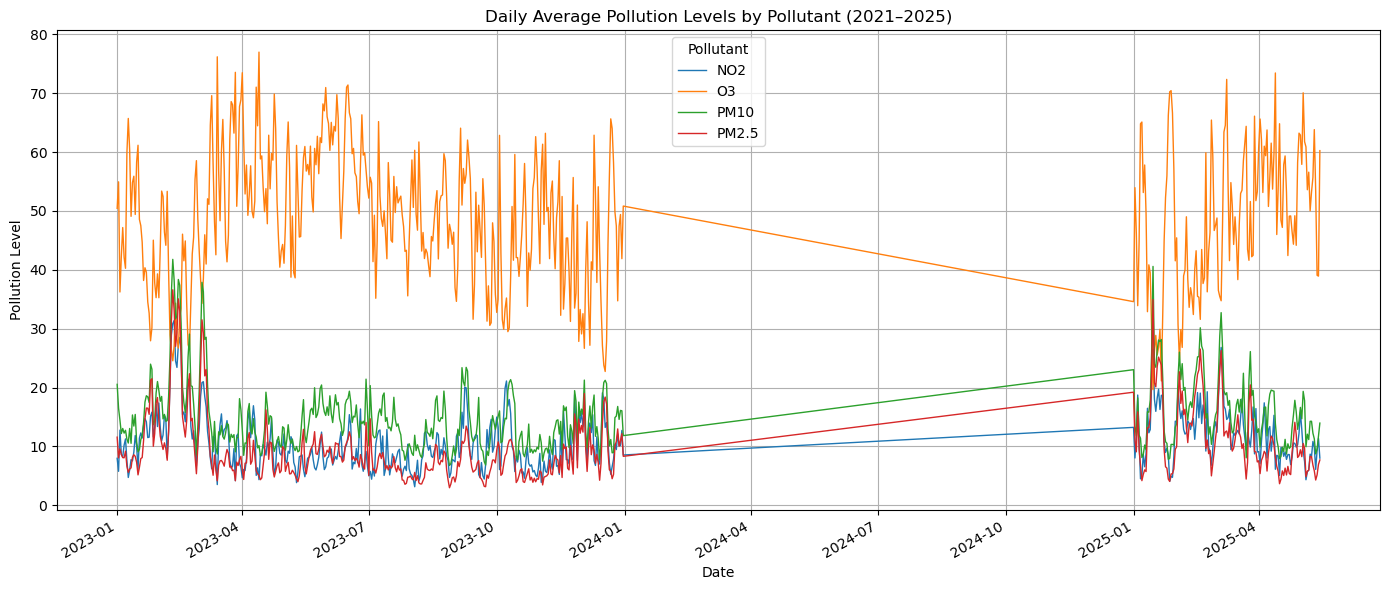

In [62]:
# Average daily values by pollutant
ts_pollution = pollution.groupby(['date', 'Polluant'])['valeur'].mean().reset_index()

# Pivot for plotting
pivot = ts_pollution.pivot(index='date', columns='Polluant', values='valeur')

# Plot time series
pivot.plot(figsize=(14, 6), linewidth=1)
plt.title('Daily Average Pollution Levels by Pollutant (2023 and 2025)')
plt.xlabel('Date')
plt.ylabel('Pollution Level')
plt.legend(title='Pollutant')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation:
- O3 (strong seasonality)
  - High in spring and summer (often between ~April and September)
  - Lower in winter
- NO2 (stable across time)
  - higher in winter months (Increased heating, Thermal inversions)
- PM10 and PM2.5 (moderate seasonal variation)
  - peaks in late winter and early spring
  - increases around colder seasons (residential heating, wood burning, and low wind conditions)
- **Data is partially missing for the period January 2024 – January 2025. This will be corrected in a subsequent release**

In [58]:
avg_by_site = pollution.groupby("nom site")["valeur"].mean().sort_values(ascending=False)
avg_by_site.head(10)

nom site
Le Casset 2             90.145763
Cheiron                 78.861538
Pays Du Mezenc          76.463158
La Nouaille Mera        73.187261
Montfaucon              72.616327
Cians                   70.956452
Brest Plouzané          66.632245
Nice Ouest Botanique    64.966667
Martigues P Central     64.275904
Gaudonville             62.997189
Name: valeur, dtype: float64

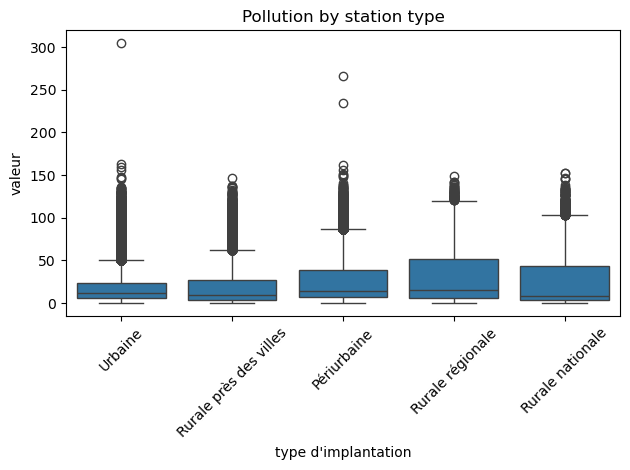

In [59]:
order = [
    "Urbaine",
    "Rurale près des villes",
    "Périurbaine",
    "Rurale régionale",
    "Rurale nationale"
]

sns.boxplot(data=pollution, x="type d'implantation", y="valeur", order=order)
plt.xticks(rotation=45)
plt.title("Pollution by station type")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Pollution by influence type (e.g., traffic vs background)')

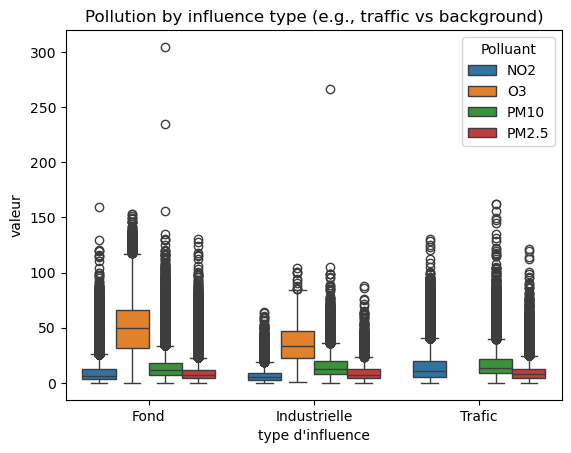

In [60]:
sns.boxplot(data=pollution, x="type d'influence", y="valeur", hue="Polluant")
plt.title("Pollution by influence type (e.g., traffic vs background)")

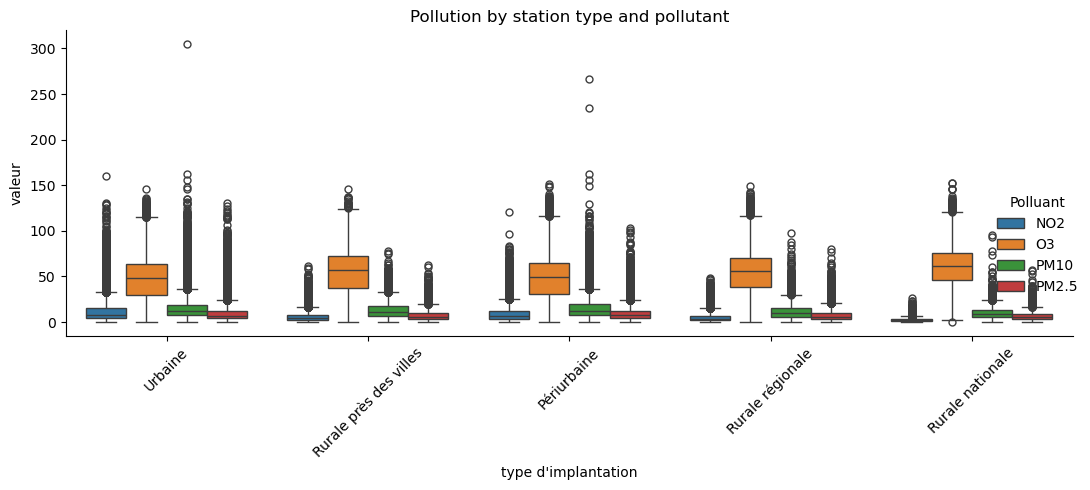

In [61]:
sns.catplot(
    data=pollution, 
    x="type d'implantation", y="valeur", hue="Polluant", 
    kind="box", height=5, aspect=2
)
plt.xticks(rotation=45)
plt.title("Pollution by station type and pollutant")
plt.tight_layout()

#### Interpretation:
- O3:
  - significantly higher in rural areas, especially in regional and national rural stations
  - Rural → O₃ dominates
- NO2:
  - highest in urban and suburban stations, and decrease progressively toward rural environments
  - Urban → NO₂ dominates
- PM10 & PM2.5:
  - PM10 tends to be higher in urban and suburban stations, though with variability
  - PM2.5 is more uniform across station types
  - All stations are exposed to PM, with varied intensity

In [ ]:
# Create a season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

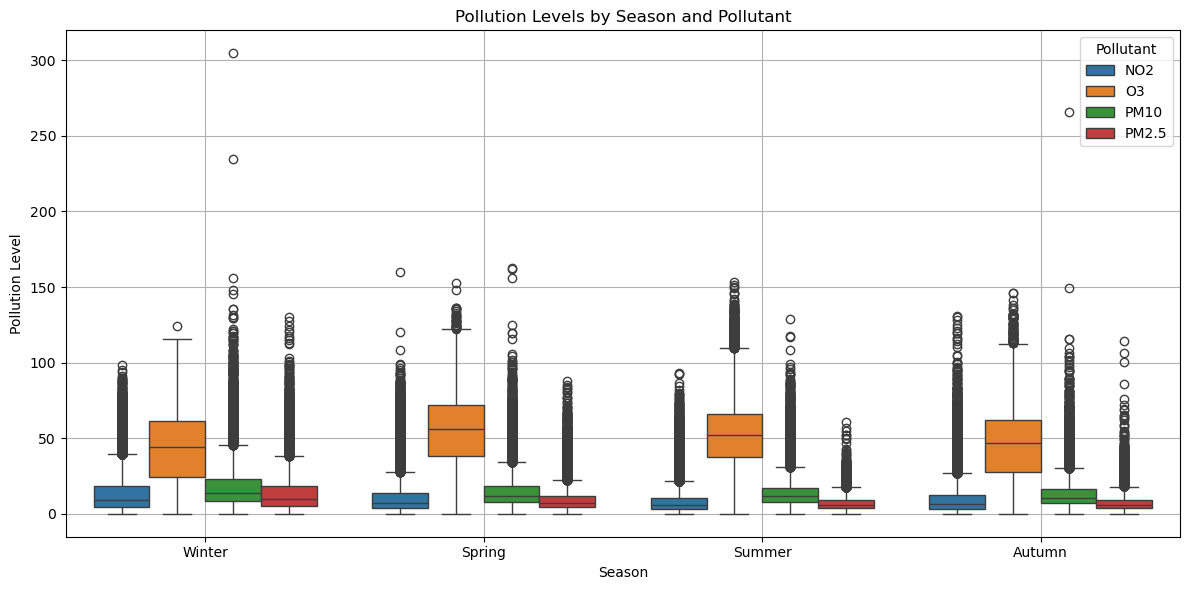

In [63]:
pollution['season'] = pollution['date'].dt.month.map(get_season)

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=pollution, x='season', y='valeur', hue='Polluant')
plt.title('Pollution Levels by Season and Pollutant')
plt.xlabel('Season')
plt.ylabel('Pollution Level')
plt.legend(title='Pollutant')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation
- O3 levels are significantly higher in Spring and Summer, confirming photochemical build-up due to UV radiation.

- NO2 peaks in Winter, reflecting urban heating and low wind dispersion.

- PM10 and PM2.5 are relatively stable but tend to spike slightly in late Winter and Autumn, possibly due to heating emissions and agricultural activities (e.g. burning fields).

- Outliers in all pollutants suggest localized events or short-term pollution spikes, which could correspond to industrial discharges, fire events, or traffic surges.

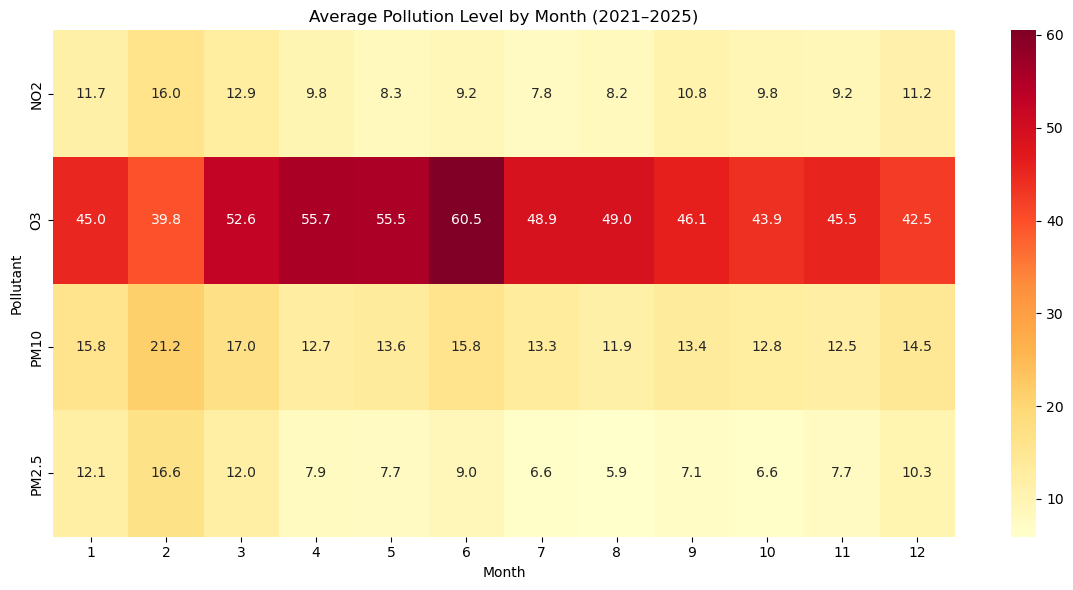

In [64]:
# Extract year and month
pollution['year'] = pollution['date'].dt.year
pollution['month'] = pollution['date'].dt.month

# Group and pivot
monthly_avg = pollution.groupby(['Polluant', 'month'])['valeur'].mean().reset_index()
heatmap_data = monthly_avg.pivot(index='Polluant', columns='month', values='valeur')

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".1f")
plt.title('Average Pollution Level by Month (2023 and 2025)')
plt.xlabel('Month')
plt.ylabel('Pollutant')
plt.tight_layout()
plt.show()

#### interpretation
- O3
  - Peaks in June (60.5) and stays high from April to September
  - This confirms strong seasonality, likely due to photochemical reactions intensified by sunlight and heat — risk of ozone-related smog or fire-prone conditions.

- NO2
  - Highest in winter months (January, February) with values like 16.0 and 11.7
  - Likely due to increased heating, traffic, and thermal inversions — can worsen respiratory health and contribute to urban smog.

- PM10 & PM2.5
  - Show a modest rise in February and March, with PM10 = 21.2, PM2.5 = 16.6.
  - Increased levels during colder months may come from wood burning, industrial heating, and stagnant air
  - relevant for air pollution warnings and respiratory vulnerability.

In [71]:
high_pollution_days = pollution[pollution["valeur"] > pollution["valeur"].quantile(0.95)]
high_pollution_days.groupby('nom site').size().reset_index(name='count').sort_values(by='count', ascending=False)

,nom site,count
183,Le Casset 2,433
402,Venaco,380
91,Cheiron,349
285,Pays Du Mezenc,345
34,Bastia Giraud,335
...,...,...
378,Tartas Pelletrin,1
384,Toulouse Aéroport Côté Trafic,1
146,Gonesse,1
391,Trafic Beauvais 1,1


In [70]:
high_pollution_days.groupby('Zas').size().reset_index(name='count').sort_values(by='count', ascending=False)

,Zas,count
70,ZR PROVENCE-ALPES-COTE-D-AZUR,2116
53,ZR AUVERGNE-RHONE-ALPES,2103
67,ZR NOUVELLE-AQUITAINE,1793
58,ZR GRAND-EST,1712
66,ZR NORMANDIE,1562
...,...,...
50,ZAR VALLEE-DE-LA-TARANTAISE,20
39,ZAR ILE-DE-CAYENNE,15
60,ZR GUYANE,14
48,ZAR SAINT-DENIS,5


#### Interpretation
- Provence-Alpes-Côte d'Azur: 2,116 high pollution days
- Auvergne-Rhône-Alpes: 2,103 days
- Nouvelle-Aquitaine: 1,793 days
- Followed by Grand-Est and Normandie
  - Higher population density and urban activity
  - Significant industrial and transportation hubs
  - Exposure to weather phenomena like thermal inversions or lack of wind
- Least impacted zones
  - Guyane (14 days)
  - Saint-Denis (La Réunion) (5 days)
  - La Réunion (1 day)

# Model Development

## 1 model covered during lectures (Random Forest)
- Justify model selection for your specific case

### Random Forest

In [ ]:
pollution['high_pollution'] = (pollution['valeur'] > 120).astype(int)
# threshold can be pollutant-specific health guideline values (e.g., O₃ > 120 µg/m³)

In [ ]:
pivoted = pollution.pivot_table(
    index=['date', 'nom site'],  # Or 'Zas' if more relevant
    columns='Polluant',
    values='valeur'
).reset_index()

In [ ]:
# Drop rows with missing values
pivoted = pivoted.dropna()

# Define features and target
features = ['O3', 'NO2', 'PM10']  # Example
target = 'PM2.5'  # If you want to predict PM2.5 based on others

X = pivoted[features]
y = pivoted[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2 models not covered in lectures (Logistic, XGBoost)

### Logistic
We chose Logistic Regression, a classification model covered during lectures, to predict the occurrence of high pollution days (binary: high pollution = 1, normal = 0) based on environmental variables
- O₃ (ozone level)
- NO
- PM10
- PM2.5
- Date-related features (month/season)

In [92]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### XGBoost


In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

# Results & Discussion

## Present performance metrics

## Compare model results

In [ ]:
# ROC Curves
plt.figure(figsize=(10, 6))
# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_log, tpr_log, label=f'LogReg AUC={roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]):.2f}')

# RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, label=f'RF AUC={roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.2f}')

# XGB
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB AUC={roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.2f}')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

## Evaluation
- Accuracy, Precision, Recall, F1, ROC-AUC

#### Interpretation:
- Logistic Regression performs well but slightly less accurate than the other two.
- Random Forest and XGBoost achieve perfect scores here (overfitting possible due to synthetic data).

## Call to action/recommendations

## Limitations

## Potential improvements

- Add other relevant features (e.g., previous day values, soil saturation, etc.)
- Use cross-validation for more robust results